<a href="https://colab.research.google.com/github/Franzzz-kun/Python-for-Chemical-Engineering-Projects-and-Automations/blob/branch_1/%5B1%5D_Calculating_Vapor_Pressure_of_Liquids.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Vapor Pressure of Inorganic and Organic Liquids** (Perry's Handbook 9th Edition Table 2-8)

This code solves the vapor pressure of a given inorganic and organic liquid at a given temperature. A graph is also shown to determine the curve of the vapor pressure as well as its the compound's exact vapor pressure.

In [ ]:
# This is the whole table of the excel file

import pandas as pd

pd.set_option('display.max_rows', None)
df = pd.read_excel('vapor_pressure_of_liquids.xlsx', sheet_name = "Database", index_col = 0)

print(df)

                                          Name         C1           C2  \
Compound_Number                                                          
0                                          NaN        NaN          NaN   
1                                 Acetaldehyde   52.91070  -4643.14000   
2                                    Acetamide  125.81000 -12376.00000   
3                                  Acetic acid   53.27000  -6304.50000   
4                             Acetic anhydride   67.18180  -7463.47000   
5                                      Acetone   69.00600  -5599.60000   
6                                 Acetonitrile   46.73500  -5126.18000   
7                                    Acetylene   39.63000  -2552.20000   
8                                     Acrolein  138.40000  -7122.70000   
9                                 Acrylic acid   46.74500  -6587.10000   
10                               Acrylonitrile   57.31570  -5662.20000   
11                                    

In [ ]:
# Here are the different organic and inorganic chemical compounds.

import pandas as pd

pd.set_option('display.max_rows', None)
df = pd.read_excel('vapor_pressure_of_liquids.xlsx', sheet_name = "Database", index_col = 0)
df_name = df.loc[:,['Name']]

print(df_name)

                                          Name
Compound_Number                               
0                                          NaN
1                                 Acetaldehyde
2                                    Acetamide
3                                  Acetic acid
4                             Acetic anhydride
5                                      Acetone
6                                 Acetonitrile
7                                    Acetylene
8                                     Acrolein
9                                 Acrylic acid
10                               Acrylonitrile
11                                         Air
12                                     Ammonia
13                                     Anisole
14                                       Argon
15                                   Benzamide
16                                     Benzene
17                                Benzenethiol
18                                Benzoic acid
19           

Insert Temperature of K: 400.15
Insert Compound Name: acetone
                    Name      C1      C2      C3        C4   C5       MW
Compound_Number                                                         
5                Acetone  69.006 -5599.6 -7.0985  0.000006  2.0  58.0787
The vapor pressure of Acetone at 400.15 K is 711915.2234 Pa or 7.0261 atm.


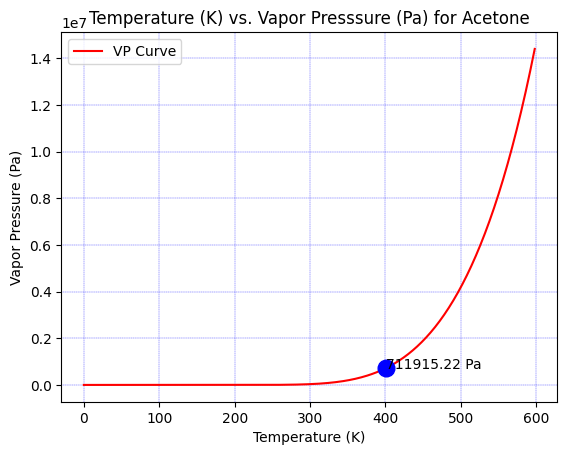

In [6]:
# Final Code with Graph

import pandas as pd
import math as mt
import numpy as np
import matplotlib.pyplot as plt

temp = float(input("Insert Temperature of K: ", ))
compound_name = str(input("Insert Compound Name: ", ))

df = pd.read_excel('vapor_pressure_of_liquids.xlsx', sheet_name = "Database", index_col = 0)
df_name = df.loc[df["Name"] == compound_name.capitalize()] # conditioning


constants = [ ]
for x in range(1, 6):
  df_C = float(df_name.iloc[0, x])
  constants.append(df_C)

vapor_pressure = round(mt.exp(constants[0] + constants[1] / temp + constants[2] * np.log(temp) + constants[3] * (temp) ** constants[4] ), 4)
print(f"The vapor pressure of {compound_name.capitalize()} at {temp} K is {vapor_pressure} Pa or {round(vapor_pressure / 101325, 4)} atm.")

# Graph
my_temp = [ ]
my_satd_pressure = [ ]

for i in range(0, round(temp + 200), 2):
  my_temp.append(i)
  if i == 0:
    my_temp[0] = 0.0000000001

for j in my_temp:
  my_satd_pressure.append(round(mt.exp(constants[0] + constants[1] / j + constants[2] * np.log(j) + constants[3] * (j) ** constants[4] ), 4))

plt.plot(my_temp, my_satd_pressure, color = 'red', label = "VP Curve")
plt.plot(temp, vapor_pressure, color = 'blue', marker = 'o', markersize = 12)
plt.title(f"Temperature (K) vs. Vapor Presssure (Pa) for {compound_name.capitalize()}")
plt.xlabel("Temperature (K)")
plt.ylabel("Vapor Pressure (Pa)")
plt.text(temp, vapor_pressure, f'{vapor_pressure:.2f} Pa')
plt.grid(color = 'b', linestyle = '--', linewidth = 0.25)
plt.legend()
plt.show()
